# 2D Wang-Landau — joint (E, N) random walk, mu as a free post-processing parameter

This is the main result of the project: a Wang-Landau random walk over the
**joint** density of states g(E, N), where `E` is the bond (interaction)
energy only and `N` is the particle number. Unlike the 1D notebook, the
chemical potential `mu` is **not** fixed during the simulation — it only
enters afterwards, when building the grand-canonical partition function
Xi(T, mu) = sum_{E,N} g(E, N) * exp(-(E - mu*N)/T).

Because g(E, N) does not depend on T or mu, it only needs to be computed
**once**; every quantity below (at any T, any mu, or a whole grid of both)
is then a cheap weighted sum over this single precomputed table — no new
Monte Carlo run is required.

See the top-level `README.md` for the physical background: the Ising <->
lattice gas mapping, the particle-hole symmetry that fixes mu = -2*eps as
the special point where a genuine phase transition exists, and why
Wang-Landau (rather than plain Metropolis) is the right tool for a system
with a first-order transition.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Physical parameters

`E` (bond energy only, no mu term) ranges over `[-2*L**2, 0]` and `N` over `[0, L**2]`. Since `E` can be negative, `offset_E` shifts it into a valid, non-negative NumPy index range for `lng`/`H`, which are now 2D tables indexed by `(E + offset_E, N)`.

In [ ]:
# ============================================================
# PHYSICAL PARAMETERS
# ============================================================

eps = 1
kb = 1.0
L = 8

Emin = -2 * L * L
Emax = 0
offset_E = 2 * L ** 2          # shift so that E + offset_E is a valid array index
E = np.arange(Emin, Emax + 1)

Nmin = 0
Nmax = L * L
N = np.arange(Nmin, Nmax + 1)

e_bins = len(E)
n_bins = len(N)
lng = np.zeros((e_bins, n_bins))   # ln g(E, N), joint density of states
H = np.zeros((e_bins, n_bins))     # visit histogram, used for the flatness check
ln_f = 1

## Initial configuration

Note that `bond_energy` here only computes the interaction term (`-eps * bonds`) — unlike the 1D notebook, `mu * N` is **not** included, since mu is no longer fixed during the walk.

In [ ]:
# ============================================================
# INITIAL CONFIGURATION
# ============================================================

def bond_energy(n):
    """Bond (interaction) energy only: E = -eps * (occupied nearest-neighbor bonds).
    Does not include any mu*N term - mu is a free parameter used only in
    post-processing."""
    bonds = np.sum(n * np.roll(n, -1, axis=1)) + np.sum(n * np.roll(n, -1, axis=0))
    return -eps * bonds

rng = np.random.default_rng(42)          # seeded RNG, for reproducibility
n = rng.integers(0, 2, size=(L, L))      # random LxL matrix of occupation numbers
E0 = bond_energy(n)
N0 = np.sum(n)

## Single-site flip: incremental (E, N) differences

Flipping site `(i, j)` changes both the bond energy and the particle number by an O(1) amount, computed directly from the four neighbors instead of recomputing the whole lattice.

In [ ]:
# ============================================================
# INITIAL MOVE
# ============================================================

i = rng.integers(0, n.shape[0])   # pick a random site
j = rng.integers(0, n.shape[1])

def bond_energy_difference(n, i, j, L):
    """O(1) bond-energy change from flipping site (i, j)."""
    return (1 - 2 * n[i, j]) * (
        -eps * (n[(i + 1) % L, j] + n[(i - 1) % L, j] + n[i, (j - 1) % L] + n[i, (j + 1) % L])
    )

deltaE = bond_energy_difference(n, i, j, L)
Enew = E0 + deltaE

def particle_number_difference(n, i, j):
    """+1 if the site becomes occupied, -1 if it becomes empty."""
    return (1 - 2 * n[i, j])

deltaN = particle_number_difference(n, i, j)
Nnew = N0 + deltaN

delta = lng[E0 + offset_E, N0] - lng[Enew + offset_E, Nnew]

## Wang-Landau main loop

Same algorithm as the 1D case, generalized to the joint (E, N) table: accept a proposed flip with probability min(1, g(E_old,N_old)/g(E_new,N_new)); either way, deposit `ln_f` into `lng` and one count into `H` at the current state; check flatness periodically and halve `ln_f` when the visited part of `H` is flat enough; stop when `ln_f < 1e-4`.

Note the flatness threshold here (`1e-4`) is looser than the 1D run's (`1e-8`): the (E, N) table has far more bins than the 1D energy axis alone, so full 1e-8 convergence would be considerably more expensive, and 1e-4 was found to already give a well-converged g(E, N) for the purposes of this project. On an 8x8 lattice this loop runs for about 61 million single-site trial moves (a few minutes).

In [ ]:
# ============================================================
# WANG-LANDAU MAIN LOOP
# ============================================================

Eold = E0.copy()
Nold = N0.copy()
n_new = n.copy()
step_count = 0
p = 0.8            # flatness criterion
n_frames = []

while ln_f > 1e-4:
    r = rng.uniform(0, 1)
    if delta >= 0 or r < np.exp(delta):
        n_new[i, j] = 1 - n_new[i, j]
        Eold = Enew.copy()
        Nold = Nnew.copy()

    lng[Eold + offset_E, Nold] += ln_f
    H[Eold + offset_E, Nold] += 1

    i = rng.integers(0, n.shape[0])
    j = rng.integers(0, n.shape[1])
    deltaE = bond_energy_difference(n_new, i, j, L)
    deltaN = particle_number_difference(n_new, i, j)
    Enew = Eold + deltaE
    Nnew = Nold + deltaN
    delta = lng[Eold + offset_E, Nold] - lng[Enew + offset_E, Nnew]

    step_count += 1
    if step_count % (100 * L ** 2) == 0:
        mask = H[H > 0]
        threshold = np.mean(mask) * p
        H_min = np.min(mask)
        if H_min >= threshold:
            ln_f = 0.5 * ln_f       # halve (not sqrt), since we work with logarithms
            Hold = H.copy()
            H = np.zeros((e_bins, n_bins))

    if step_count % (1000 * L ** 2) == 0:
        n_frames.append(n_new.copy())

## Normalizing ln g(E, N)

Wang-Landau only determines g(E, N) up to an overall multiplicative constant. It is fixed using the one thing we know exactly: the total number of microstates of an LxL lattice gas is 2^(L^2), so `sum(g(E,N)) = 2**(L*L)`, i.e. `log-sum-exp(lng) = L**2 * log(2)`, summed over the whole table.

This is done right after the main loop (and before plotting `lng` below), so that every figure and every quantity from here on refers to the properly normalized ln g(E, N), not the raw, arbitrarily-offset values `lng` holds immediately after the random walk.

In [ ]:
# Normalization constant for ln g(E,N)

ln_sum_lng = np.max(lng) + np.log(np.sum(np.exp(lng - np.max(lng))))
cte = L ** 2 * np.log(2) - ln_sum_lng
lng = lng + cte

### ln g(E, N) and the visit histogram

Both are masked with `Hold > 0` so that only bins the walk actually visited are shown (unvisited bins would otherwise appear misleadingly as `lng = 0`, or after normalization, as a large uniform offset). The accessible (E, N) region is a diagonal band: for a given N, the bond energy is bounded by how densely those N particles can be packed together.

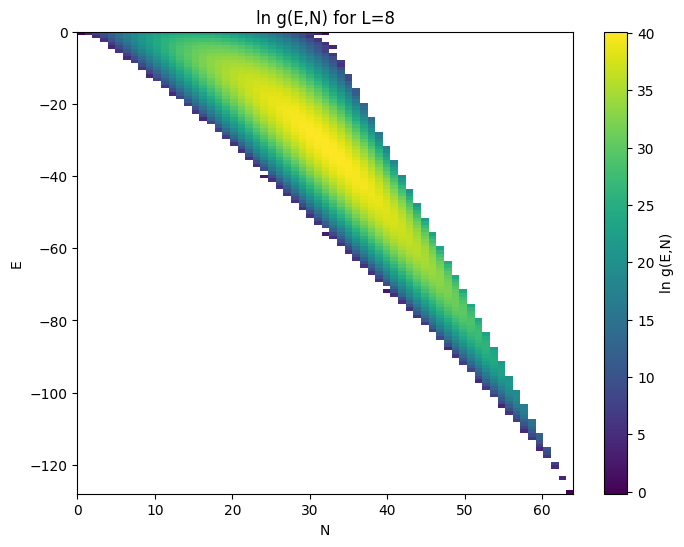

In [ ]:
lng_to_plot = np.where(Hold > 0, lng, np.nan)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    lng_to_plot,
    extent=[0, L**2, -2*L**2, 0],    # [N_min, N_max, E_min, E_max]
    origin='lower',                   # E increases upward, as is conventional
    aspect='auto',                    # the E range is much larger than the N range
    cmap='viridis'
)
ax.set_xlabel('N')
ax.set_ylabel('E')
ax.set_title(f'ln g(E,N) for L={L}')
fig.colorbar(im, ax=ax, label='ln g(E,N)')
plt.show()

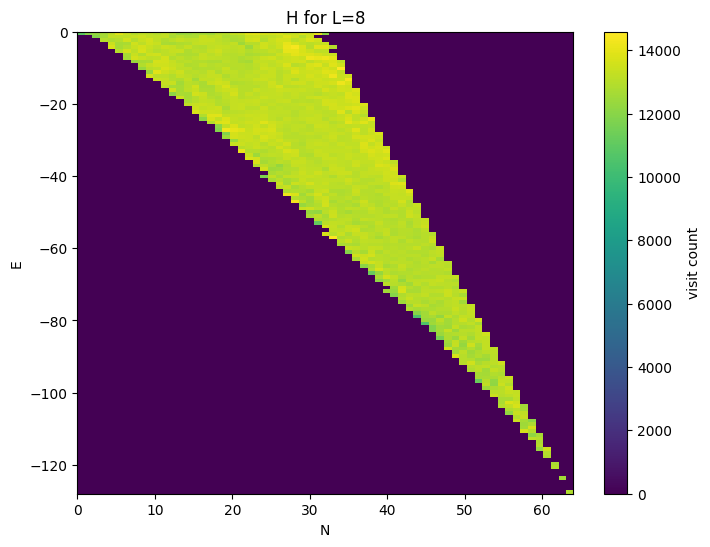

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    Hold,
    extent=[0, L**2, -2*L**2, 0],
    origin='lower',
    aspect='auto',
    cmap='viridis'
)
ax.set_xlabel('N')
ax.set_ylabel('E')
ax.set_title(f'H for L={L}')
fig.colorbar(im, ax=ax, label='visit count')
plt.show()

## Grand partition function Xi(T, mu)

`mask = Hold > 0` restricts every sum below to (E, N) bins that were actually visited. `Ereshape`/`Nreshape` broadcast the 1D `E` and `N` arrays into 2D grids matching the shape of `lng`, so that `E` and `N` values can be paired elementwise with each table entry.

This first evaluation fixes mu at the symmetric point (mu = -2*eps) as a sanity check — see the README for why this value is special.

In [ ]:
# Grand partition function Xi(T, mu)

temperature = 1.0
beta = 1.0 / (temperature * kb)
mu = -2 * eps
mask = Hold > 0
Ereshape, Nreshape = np.broadcast_arrays(E[:, None], N[None, :])

Xi_terms = lng[mask] - beta * (Ereshape[mask] - mu * Nreshape[mask])
ln_Xi = np.max(Xi_terms) + np.log(np.sum(np.exp(Xi_terms - np.max(Xi_terms))))
print(f"ln Xi = {ln_Xi}")

ln Xi = 16.576021577795967

## Specific heat Cv(T) at fixed mu = -2*eps

The quantity that is guaranteed non-negative by thermodynamic stability is not `d<E>/dT` at fixed mu (E = bond energy alone), but `d<H>/dT` at fixed mu, where `H = E - mu*N` is the *full* grand-canonical Hamiltonian — the same quantity the 1D notebook's single energy variable represented all along, since there mu was already baked into the energy from the start. Averaging just `E` instead of `H` can (and does) produce a locally negative "specific heat" near the coexistence line, since it ignores the correlated fluctuations of E and N — a genuine, well-known feature of the grand-canonical ensemble away from the symmetric point, not a bug. `meanH` below is `<E - mu*N>`.

The result is the same clean, symmetric peak as the 1D run (Tc ~ 0.589 for L=8), confirming the two independent calculations agree.

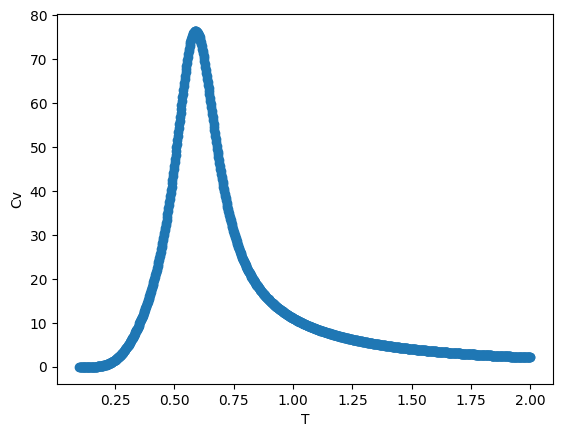

Tc = 0.5887887887887888

In [ ]:
# Specific heat Cv(T) at fixed mu

mu = -2 * eps
T = np.linspace(0.1, 2, 1000)
beta = 1.0 / (T * kb)
meanH = []
for b in beta:
    exponent = lng[mask] - b * (Ereshape[mask] - mu * Nreshape[mask])
    w = np.exp(exponent - np.max(exponent))   # each weight w in [0, 1]: Boltzmann weight of that state
    meanH.append(np.sum((Ereshape[mask] - mu * Nreshape[mask]) * w) / np.sum(w))  # <E - mu*N>, the full grand energy

meanH = np.array(meanH)
Cv = np.gradient(meanH, T)

plt.scatter(T, Cv)
plt.xlabel('T')
plt.ylabel('Cv')
plt.show()

Tc = T[np.argmax(Cv)]
print(f"Tc = {Tc}")

## <N>(mu) at fixed T

**Note:** this cell fixes `temperature = 1.0`, which is *above* Tc (~0.589). Above Tc there is no phase transition, so `<N>(mu)` should vary smoothly (a soft crossover) rather than jump discontinuously — which is exactly what the plot below shows. Fixing a temperature well below Tc instead produces a sharp step in `<N>` right at mu = -2*eps, the signature of the first-order transition (see the muc estimate below, and the full phase-diagram cells further down for the T < Tc behaviour).

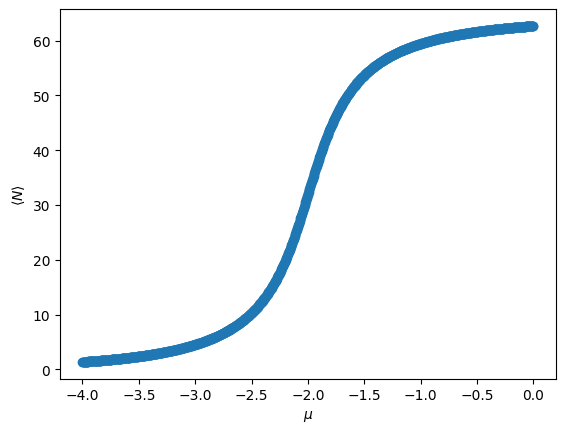

mu_c = -1.9979979979979978

In [ ]:
# <N>(mu) at fixed T

temperature = 1.0
beta = 1.0 / (temperature * kb)
mu = np.linspace(-4 * eps, 0, 1000)
meanN = []
for m in mu:
    exponent = lng[mask] - beta * (Ereshape[mask] - m * Nreshape[mask])
    w = np.exp(exponent - np.max(exponent))
    meanN.append(np.sum(Nreshape[mask] * w) / np.sum(w))

meanN = np.array(meanN)
plt.scatter(mu, meanN)
plt.xlabel(r'$\mu$')
plt.ylabel(r'$\langle N\rangle$')
plt.show()

muc = mu[np.argmax(np.gradient(meanN, mu))]
print(f"mu_c = {muc}")

## Full phase diagram: Cv(T, mu) and <N>(T, mu)

Repeating the calculation above for a whole grid of mu values (instead of just mu = -2*eps, or just T = 1.0) maps out the full phase diagram.

**A performance note.** A direct translation of the single-point calculation into a double `for` loop over 1000 T values times 1000 mu values means one million individual Python-level reductions over the `mask`-sized arrays, which is unnecessarily slow — most of the cost is Python loop overhead, not actual floating-point work. Since the T-dependence enters only through `beta` while mu only shifts `X = E - mu*N`, the inner loop over T can be vectorized: for a fixed mu, `X` is a single 1D array, and the whole `exponent(T)` array (mask size x 1000 temperatures) is built and reduced in one NumPy call. This cuts the loop from 1,000,000 to 1,000 iterations, and computes `meanH` (-> Cv) and `meanN` together in the same pass, since both reuse the same Boltzmann weights `w`. It reproduces the loop version exactly (same math, just batched), just roughly an order of magnitude faster.

The Cv map shows the classic shape of a first-order line terminating at a critical point: a narrow, tall ridge of large fluctuations running along mu = -2*eps for T < Tc, closing to a single point exactly at (Tc, -2*eps), and no structure at all for T > Tc. The companion <N>(T, mu) map shows the same story directly in the order parameter: a sharp jump between the dilute and dense phases below Tc, smoothing into a continuous crossover above it.

In [ ]:
# Cv(T, mu) and <N>(T, mu) over the full grid, computed together

T = np.linspace(0.1, 2, 1000)
beta = 1.0 / (T * kb)
mu = np.linspace(-4 * eps, 0, 1000)

E_masked = Ereshape[mask]      # (M,)
N_masked = Nreshape[mask]      # (M,)
lng_masked = lng[mask]         # (M,)

meanH = np.zeros((len(mu), len(T)))
meanN = np.zeros((len(mu), len(T)))

for j, m in enumerate(mu):
    X = E_masked - m * N_masked                                    # (M,), grand energy at this mu
    exponent = lng_masked[:, None] - beta[None, :] * X[:, None]     # (M, len(T))
    exponent -= exponent.max(axis=0, keepdims=True)
    w = np.exp(exponent)
    w_sum = w.sum(axis=0)
    meanH[j, :] = (X[:, None] * w).sum(axis=0) / w_sum
    meanN[j, :] = (N_masked[:, None] * w).sum(axis=0) / w_sum

Cv = np.gradient(meanH, T, axis=1)

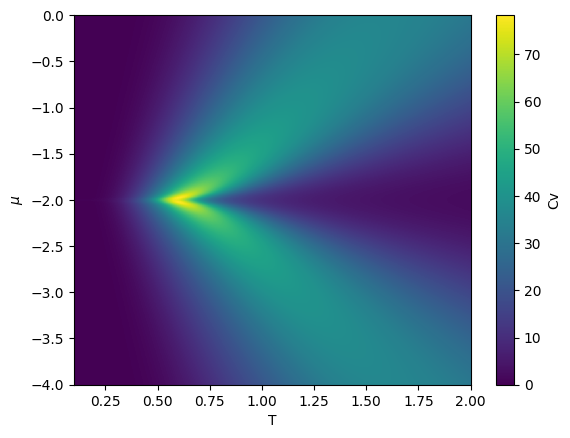

In [ ]:
pcm = plt.pcolormesh(T, mu, Cv, shading='auto')
plt.xlabel('T')
plt.ylabel(r'$\mu$')
cbar = plt.colorbar(pcm)
cbar.set_label('Cv')
plt.show()

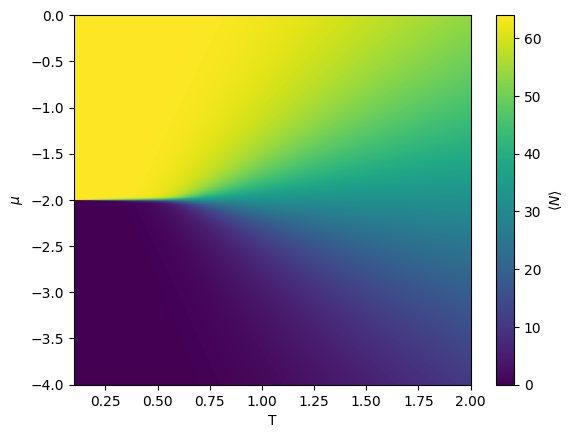

In [ ]:
pcm = plt.pcolormesh(T, mu, meanN, shading='auto')
plt.xlabel('T')
plt.ylabel(r'$\mu$')
cbar = plt.colorbar(pcm)
cbar.set_label(r'$\langle N\rangle$')
plt.show()